In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

#ucitavanje:

In [3]:
def ucitaj_fajl(putanja):
    podaci = []

    with open(putanja, "r", encoding="utf-8-sig") as f:

        #preskacemo zaglavlje:
        next(f)

        for broj_reda, linija in enumerate(f, start = 2):

            linija = linija.rstrip("\n\r")

            #ako je prazan red, preskoci:
            if not linija.strip():
                continue

            #prvi ; razdvaja article_id i ostatak:
            prvi = linija.find(";")

            if prvi == -1:
                print(f"Problem u redu {broj_reda}: nema prvog ;")
                continue

            article_id = linija[:prvi]

            #drugi ; razdvaja source i full_text:
            drugi = linija.find(";", prvi + 1)

            if drugi == -1:
                print(f"Problem u redu {broj_reda}: nema drugog ;")
                continue

            source = linija[prvi + 1:drugi]

            #sve nakon drugog ; je tekst:
            full_text = linija[drugi + 1:]

            podaci.append([
                article_id,
                source,
                full_text
            ])

    return pd.DataFrame(
        podaci,
        columns=["article_id", "source", "full_text"]
    )

#UCITAVANJE FAJLOVA:
train = ucitaj_fajl(
    r"C:\Users\KORISNIK\Desktop\training.csv"
)

test = ucitaj_fajl(
    r"C:\Users\KORISNIK\Desktop\test.csv"
)

#PROVERA:

In [4]:
print("Kolone:")
print(train.columns)

print("\nPrvih 5 redova:")
print(train.head())

print("\nBroj redova:")
print("Training:", len(train))
print("Test:", len(test))

Kolone:
Index(['article_id', 'source', 'full_text'], dtype='object')

Prvih 5 redova:
  article_id source                                          full_text
0       2017     N1  "(intervju) živković: predložio sam formiranje...
1       3949   Nova  "video studenti pomogli bivšem srpskom repreze...
2       2554   Nova  "blog studentska pobuna uživo na rts: podrška ...
3       1490  Danas  studenti u blokadi apelovali da univerzitet u ...
4        584   Blic  "studenti u blokadi organizuju skup podrške re...

Broj redova:
Training: 4154
Test: 1039


#ISPITIVANJE BALANSIRANOSTI PODATAKA:
zavisna promenljiva je "source"

In [5]:
print("\n================ Trening skup ================")

print("\nBroj tekstova po novini:")
print(train["source"].value_counts())

print("\nProcentualna zastupljenost:")
print(train["source"].value_counts(normalize = True) * 100)


print("\n================ Test skup ================")

print("\nBroj tekstova po novini:")
print(test["source"].value_counts())

print("\nProcentualna zastupljenost:")
print(test["source"].value_counts(normalize=True) * 100)


================ Trening skup ================

Broj tekstova po novini:
source
Nova        1332
Politika     897
Danas        715
Blic         612
N1           423
Kurir        175
Name: count, dtype: int64

Procentualna zastupljenost:
source
Nova        32.065479
Politika    21.593645
Danas       17.212325
Blic        14.732788
N1          10.182956
Kurir        4.212807
Name: proportion, dtype: float64

================ Test skup ================

Broj tekstova po novini:
source
Nova        333
Politika    224
Danas       179
Blic        153
N1          106
Kurir        44
Name: count, dtype: int64

Procentualna zastupljenost:
source
Nova        32.050048
Politika    21.559192
Danas       17.228104
Blic        14.725698
N1          10.202117
Kurir        4.234841
Name: proportion, dtype: float64


#vidimo da su podaci dosta nebalansirani: najzastupljenija je Novasa udelom od oko 32%, dok Kurir ima samo oko 4% (raspodela udela ista i na test skupu)

#PRIPREMA PODATAKA:

In [6]:
X = train["full_text"].astype(str)
y = train["source"].astype(str).str.strip()

X_test = test["full_text"].astype(str)
y_test = test["source"].astype(str).str.strip()


print("Broj u trening skupu:", len(X))
print("Broj u test skupu:", len(X_test))

print("\nKlase:")
print(sorted(y.unique()))

print("\nBroj klasa:", y.nunique())
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.20,random_state=279,stratify=y)

print("Training:", len(X_train))
print("Validacioni:", len(X_val))
print("Test:", len(X_test))

Broj u trening skupu: 4154
Broj u test skupu: 1039

Klase:
['Blic', 'Danas', 'Kurir', 'N1', 'Nova', 'Politika']

Broj klasa: 6
Training: 3323
Validacioni: 831
Test: 1039


#pretvaramo tesktove u numericke karakteristike, da bi ih model koristio:

In [7]:
tfidf = TfidfVectorizer(lowercase=True, max_features=50000,ngram_range=(1, 2),min_df=2,max_df=0.95,sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Trening TF-IDF:", X_train_tfidf.shape)
print("Validatcioni TF-IDF:", X_val_tfidf.shape)
print("Test TF-IDF:", X_test_tfidf.shape)

Trening TF-IDF: (3323, 50000)
Validatcioni TF-IDF: (831, 50000)
Test TF-IDF: (1039, 50000)


#Pravimo funkciju za evaluaciju i ispis:

In [8]:
def evaluacija_modela(y_true, y_pred, y_proba, naziv_modela):

    accuracy = accuracy_score(y_true, y_pred)

    precision_macro = precision_score(y_true,y_pred,average="macro",zero_division=0)

    recall_macro = recall_score(y_true,y_pred,average="macro",zero_division=0)

    f1_macro = f1_score(y_true,y_pred,average="macro",zero_division=0)

    precision_weighted = precision_score(y_true,y_pred,average="weighted",zero_division=0)
    
    recall_weighted = recall_score(y_true,y_pred,average="weighted",zero_division=0)

    f1_weighted = f1_score(y_true,y_pred,average="weighted",zero_division=0)

    roc_auc = roc_auc_score(y_true,y_proba,multi_class="ovr",average="macro")

    print("\n==========================================")
    print(naziv_modela)
    print("==========================================")

    print(f"Accuracy:           {accuracy:.4f}")
    print(f"Precision (macro):  {precision_macro:.4f}")
    print(f"Recall (macro):     {recall_macro:.4f}")
    print(f"F1 (macro):         {f1_macro:.4f}")
    print(f"Precision (weighted): {precision_weighted:.4f}")
    print(f"Recall (weighted):    {recall_weighted:.4f}")
    print(f"F1 (weighted):        {f1_weighted:.4f}")
    print(f"ROC-AUC (OvR):        {roc_auc:.4f}")

    print("\nClassification report:")
    print(classification_report(y_true,y_pred,zero_division=0))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_true, y_pred))

    return {
        "Model": naziv_modela,
        "Accuracy": accuracy,
        "Precision_macro": precision_macro,
        "Recall_macro": recall_macro,
        "F1_macro": f1_macro,
        "Precision_weighted": precision_weighted,
        "Recall_weighted": recall_weighted,
        "F1_weighted": f1_weighted,
        "ROC_AUC": roc_auc
    }

#LOGISTICKA REGRESIJA

In [9]:
logreg = LogisticRegression(max_iter=2000,random_state=279) #model

logreg.fit(X_train_tfidf, y_train) #fitujemo model
y_val_pred = logreg.predict(X_val_tfidf) #prediktovanje 
y_val_proba = logreg.predict_proba(X_val_tfidf) #prediktovanje verobatnoce

rezultat_logreg = evaluacija_modela(y_val,y_val_pred,y_val_proba,"Logisticka regresija - osnovni model")



Logisticka regresija - osnovni model
Accuracy:           0.7268
Precision (macro):  0.7674
Recall (macro):     0.5675
F1 (macro):         0.5818
Precision (weighted): 0.7445
Recall (weighted):    0.7268
F1 (weighted):        0.6980
ROC-AUC (OvR):        0.9397

Classification report:
              precision    recall  f1-score   support

        Blic       0.68      0.46      0.55       122
       Danas       0.71      0.62      0.66       143
       Kurir       1.00      0.11      0.21        35
          N1       0.76      0.31      0.44        85
        Nova       0.85      1.00      0.92       267
    Politika       0.60      0.91      0.72       179

    accuracy                           0.73       831
   macro avg       0.77      0.57      0.58       831
weighted avg       0.74      0.73      0.70       831


Confusion matrix:
[[ 56  13   0   2   8  43]
 [ 10  88   0   5  17  23]
 [  4   4   4   0   1  22]
 [  2  15   0  26  20  22]
 [  0   0   0   0 267   0]
 [ 10   4   0   1

#model je ostvario accuracy od 72,7% i macro F1 od 58,2%, pri cemu najbolje prepoznaje Novu i Politiku, dok ima problema sa prepoznavanjem Kurira i N1, a visok ROC-AUC od 94% pokazuje da model dobro razlikuje klase na osnovu prediktivnih skorova


#podesavamo hiperparametar C logisticke regresije tako sto isprobavamo razlicite vrednosti i biramo onu koja daje najbolji macro F1 skor kroz 5-fold cross-validation

In [10]:
param_grid = {
    "C": [0.01, 0.1, 1, 10]
} #vise hiperparametara

logreg = LogisticRegression(max_iter=2000, random_state=27)

grid_search = GridSearchCV(estimator=logreg,param_grid=param_grid,scoring="f1_macro",cv=5,n_jobs=1) #pronalazak najbolje kombinacije hiperparametra

grid_search.fit(X_train_tfidf, y_train) #fitovanje

print("Najbolji parametri:")
print(grid_search.best_params_)

print("\nNajbolji CV F1-macro:")
print(grid_search.best_score_) #f1_macro yato sto iammo  nejednak broj tekstova po novinama, pa ne zelimo da model izgleda dobro samo zato sto dobro klasifikuje velike klase poput Nove i Politike

best_logreg = grid_search.best_estimator_ #najbolji

y_val_pred_best = best_logreg.predict(X_val_tfidf)
y_val_proba_best = best_logreg.predict_proba(X_val_tfidf)

rezultat_logreg_tuned = evaluacija_modela(y_val,y_val_pred_best, y_val_proba_best,"Logistic Regression - podešeni model")


Najbolji parametri:
{'C': 10}

Najbolji CV F1-macro:
0.6638375406455799

Logistic Regression - podešeni model
Accuracy:           0.7677
Precision (macro):  0.7683
Recall (macro):     0.6517
F1 (macro):         0.6784
Precision (weighted): 0.7716
Recall (weighted):    0.7677
F1 (weighted):        0.7569
ROC-AUC (OvR):        0.9477

Classification report:
              precision    recall  f1-score   support

        Blic       0.65      0.58      0.61       122
       Danas       0.70      0.66      0.68       143
       Kurir       1.00      0.37      0.54        35
          N1       0.65      0.41      0.50        85
        Nova       0.95      0.99      0.97       267
    Politika       0.67      0.89      0.76       179

    accuracy                           0.77       831
   macro avg       0.77      0.65      0.68       831
weighted avg       0.77      0.77      0.76       831


Confusion matrix:
[[ 71  17   0   5   2  27]
 [ 16  95   0  10   3  19]
 [  5   3  13   0   0  14]

#model je ostvario accuracy od 76,8% i macro F1 od 67,8%, pri čemu najbolje prepoznaje Novu i Politiku, dok i dalje slabije razdvaja Kurir i N1, a ROC-AUC od 94,8% pokazuje veoma dobru sposobnost razlikovanja klasa

#RANDOM FOREST:

In [11]:
rf = RandomForestClassifier(n_estimators=200,random_state=279,n_jobs=-1) #pravljenje radnom forest modela

rf.fit(X_train_tfidf, y_train) #fitovanje

y_val_pred_rf = rf.predict(X_val_tfidf) #predvidjanje
y_val_proba_rf = rf.predict_proba(X_val_tfidf) #predvidjanje veroatnoce

rezultat_rf = evaluacija_modela( y_val,y_val_pred_rf, y_val_proba_rf,"Random Forest - osnovni model")


Random Forest - osnovni model
Accuracy:           0.7461
Precision (macro):  0.7984
Recall (macro):     0.5912
F1 (macro):         0.6117
Precision (weighted): 0.7938
Recall (weighted):    0.7461
F1 (weighted):        0.7298
ROC-AUC (OvR):        0.9351

Classification report:
              precision    recall  f1-score   support

        Blic       0.80      0.47      0.59       122
       Danas       0.72      0.66      0.69       143
       Kurir       1.00      0.14      0.25        35
          N1       0.74      0.34      0.47        85
        Nova       1.00      1.00      1.00       267
    Politika       0.53      0.94      0.68       179

    accuracy                           0.75       831
   macro avg       0.80      0.59      0.61       831
weighted avg       0.79      0.75      0.73       831


Confusion matrix:
[[ 57  14   0   3   0  48]
 [  3  94   0   6   0  40]
 [  4   1   5   0   0  25]
 [  0  19   0  29   1  36]
 [  0   0   0   0 267   0]
 [  7   3   0   1   0 16

#model je ostvario accuracy od 74,6% i macro F1 od 61,2%, pri cemu savrseno prepoznaje Novu, veoma dobro Danas i Politiku, dok i dalje ima problema sa Kurirom i N1, a ROC-AUC od 93,5% pokazuje veoma dobru sposobnost razlikovanja klasa

#hiperparametri RANDOM FOREST:

In [12]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20],
    "min_samples_leaf": [1, 2]
} #hiperparametri

rf = RandomForestClassifier(random_state=279,n_jobs=-1)

grid_rf = GridSearchCV(estimator=rf,param_grid=param_grid_rf,scoring="f1_macro",cv=5,n_jobs=1) #pronalazak najbolje kombinacije hiperparametra

grid_rf.fit(X_train_tfidf, y_train) #fitovanje modela

print("Najbolji parametri:")
print(grid_rf.best_params_)

print("\nNajbolji CV F1-macro:")
print(grid_rf.best_score_)

best_rf = grid_rf.best_estimator_ #najbolji

y_val_pred_rf_best = best_rf.predict(X_val_tfidf) #predvidjanje
y_val_proba_rf_best = best_rf.predict_proba(X_val_tfidf) #predvidjanje verovatnoce

rezultat_rf_tuned = evaluacija_modela(y_val,y_val_pred_rf_best, y_val_proba_rf_best, "Random Forest - podešeni model")

Najbolji parametri:
{'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}

Najbolji CV F1-macro:
0.606419740043245

Random Forest - podešeni model
Accuracy:           0.7341
Precision (macro):  0.7973
Recall (macro):     0.5763
F1 (macro):         0.5949
Precision (weighted): 0.7881
Recall (weighted):    0.7341
F1 (weighted):        0.7165
ROC-AUC (OvR):        0.9392

Classification report:
              precision    recall  f1-score   support

        Blic       0.76      0.42      0.54       122
       Danas       0.70      0.62      0.66       143
       Kurir       1.00      0.11      0.21        35
          N1       0.82      0.36      0.50        85
        Nova       1.00      1.00      1.00       267
    Politika       0.52      0.94      0.67       179

    accuracy                           0.73       831
   macro avg       0.80      0.58      0.59       831
weighted avg       0.79      0.73      0.72       831


Confusion matrix:
[[ 51  15   0   2   0  54]
 [  6 

#Random Forest je ostvario accuracy od 73,4% i macro F1 od 59,5%, pri cemu najbolje prepoznaje Novu, dok relativno dobro razlikuje Danas i N1, ali ima problema sa Kurirom i Blicom, a ROC-AUC od 93,9% pokazuje dobru sposobnost razlikovanja klasa

#XGBoost: XGBoost ocekuje kodirane klase:

In [13]:
label_encoder = LabelEncoder() #da bismo pretvorili klase iu brojeve
y_train_xgb = label_encoder.fit_transform(y_train) #fitujemo i tranform
y_val_xgb = label_encoder.transform(y_val) #samo transform
print(label_encoder.classes_)

tfidf_xgb = TfidfVectorizer(lowercase=True,ngram_range=(1, 2), min_df=2,max_df=0.95,max_features=20000,sublinear_tf=True)

X_train_xgb = tfidf_xgb.fit_transform(X_train)
X_val_xgb = tfidf_xgb.transform(X_val)

print("XGBoost train shape:", X_train_xgb.shape)
print("XGBoost validation shape:", X_val_xgb.shape)

['Blic' 'Danas' 'Kurir' 'N1' 'Nova' 'Politika']
XGBoost train shape: (3323, 20000)
XGBoost validation shape: (831, 20000)


In [14]:
xgb = XGBClassifier( n_estimators=100,max_depth=4,learning_rate=0.1,subsample=0.8,colsample_bytree=0.8,random_state=42,n_jobs=-1,eval_metric="mlogloss")

xgb.fit(X_train_xgb, y_train_xgb)

y_val_pred_xgb = xgb.predict(X_val_xgb)
y_val_proba_xgb = xgb.predict_proba(X_val_xgb)

rezultat_xgb = evaluacija_modela(y_val_xgb, y_val_pred_xgb, y_val_proba_xgb,"XGBoost - osnovni model")



XGBoost - osnovni model
Accuracy:           0.7774
Precision (macro):  0.7621
Recall (macro):     0.6924
F1 (macro):         0.7161
Precision (weighted): 0.7862
Recall (weighted):    0.7774
F1 (weighted):        0.7746
ROC-AUC (OvR):        0.9556

Classification report:
              precision    recall  f1-score   support

           0       0.70      0.58      0.63       122
           1       0.69      0.65      0.67       143
           2       0.83      0.54      0.66        35
           3       0.74      0.54      0.63        85
           4       1.00      1.00      1.00       267
           5       0.62      0.84      0.71       179

    accuracy                           0.78       831
   macro avg       0.76      0.69      0.72       831
weighted avg       0.79      0.78      0.77       831


Confusion matrix:
[[ 71  15   1   3   0  32]
 [ 15  93   0   9   0  26]
 [  2   0  19   1   0  13]
 [  3  15   0  46   0  21]
 [  0   0   0   0 267   0]
 [ 11  12   3   3   0 150]]


#XGBoost osnovni model je ostvario accuracy od 77,7% i macro F1 od 71,6%, pri cemu najbolje prepoznaje Novu, dok relativno dobro razlikuje ostale klase, a ROC-AUC od 95,6% pokazuje veoma dobru sposobnost modela da razlikuje novine

#MULTINOMIALNI NAIVE BAYES:

In [16]:
nb = MultinomialNB() #model

nb.fit(X_train_tfidf, y_train) #fitovanje

y_val_pred_nb = nb.predict(X_val_tfidf) #predikcija
y_val_proba_nb = nb.predict_proba(X_val_tfidf) #predikcija verovatnoce

rezultat_nb = evaluacija_modela( y_val,y_val_pred_nb,y_val_proba_nb,"Multinomialni Naivni Bayes - osnovni model")


Multinomialni Naivni Bayes - osnovni model
Accuracy:           0.3983
Precision (macro):  0.4419
Recall (macro):     0.2305
F1 (macro):         0.1812
Precision (weighted): 0.4900
Recall (weighted):    0.3983
F1 (weighted):        0.2814
ROC-AUC (OvR):        0.7969

Classification report:
              precision    recall  f1-score   support

        Blic       0.60      0.02      0.05       122
       Danas       0.50      0.01      0.01       143
       Kurir       0.00      0.00      0.00        35
          N1       0.50      0.02      0.04        85
        Nova       0.36      0.99      0.53       267
    Politika       0.69      0.34      0.45       179

    accuracy                           0.40       831
   macro avg       0.44      0.23      0.18       831
weighted avg       0.49      0.40      0.28       831


Confusion matrix:
[[  3   1   0   2 101  15]
 [  0   1   0   0 136   6]
 [  1   0   0   0  34   0]
 [  0   0   0   2  79   4]
 [  0   0   0   0 265   2]
 [  1   0  

#vidimo da je ovaj model najlosijih od svih do sad

#LOGISTICKA REGRESIJA + OVERSAMPLING:

In [30]:
#Oversampling samo trening skupa:
ros = RandomOverSampler(random_state=279)

X_train_over, y_train_over = ros.fit_resample(X_train_tfidf,y_train)

print("Pre oversampling-a:")
print(y_train.value_counts())

print("\nPosle oversampling-a:")
print(y_train_over.value_counts())

Pre oversampling-a:
source
Nova        1065
Politika     718
Danas        572
Blic         490
N1           338
Kurir        140
Name: count, dtype: int64

Posle oversampling-a:
source
Blic        1065
Nova        1065
Danas       1065
Kurir       1065
N1          1065
Politika    1065
Name: count, dtype: int64


In [29]:
logreg_over = LogisticRegression(C=1, max_iter=2000,random_state=42)

logreg_over.fit(X_train_over, y_train_over)

y_val_pred_over = logreg_over.predict(X_val_tfidf)
y_val_proba_over = logreg_over.predict_proba(X_val_tfidf)

rezultat_logreg_over = evaluacija_modela(y_val,y_val_pred_over,y_val_proba_over,"LOGISTICKA REGRESIJA + OVERSAMPLING")


LOGISTICKA REGRESIJA + OVERSAMPLING
Accuracy:           0.7786
Precision (macro):  0.7310
Recall (macro):     0.7113
F1 (macro):         0.7197
Precision (weighted): 0.7774
Recall (weighted):    0.7786
F1 (weighted):        0.7772
ROC-AUC (OvR):        0.9397

Classification report:
              precision    recall  f1-score   support

        Blic       0.60      0.57      0.59       122
       Danas       0.70      0.68      0.69       143
       Kurir       0.76      0.63      0.69        35
          N1       0.60      0.59      0.60        85
        Nova       0.98      0.98      0.98       267
    Politika       0.74      0.82      0.78       179

    accuracy                           0.78       831
   macro avg       0.73      0.71      0.72       831
weighted avg       0.78      0.78      0.78       831


Confusion matrix:
[[ 70  16   3  12   0  21]
 [ 19  97   0  14   3  10]
 [  3   2  22   1   0   7]
 [  6  14   0  50   2  13]
 [  1   3   0   2 261   0]
 [ 17   7   4   4 

#model je ostvario accuracy od 77,9% i macro F1 od 72,0%, pri cemu veoma dobro prepoznaje Novu i Politiku, dok nesto slabije razlikuje Blic i N1, a ROC-AUC od 94,0% pokazuje veoma dobru sposobnost razlikovanja klasa

#LOGISTICKA REGRESIJA + UNDERSAMPLING:

In [31]:
#Undersampling samo trening skupa
rus = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = rus.fit_resample(X_train_tfidf,y_train)

print("Pre undersampling-a:")
print(y_train.value_counts())

print("\nPosle undersampling-a:")
print(y_train_under.value_counts())

Pre undersampling-a:
source
Nova        1065
Politika     718
Danas        572
Blic         490
N1           338
Kurir        140
Name: count, dtype: int64

Posle undersampling-a:
source
Blic        140
Danas       140
Kurir       140
N1          140
Nova        140
Politika    140
Name: count, dtype: int64


In [ ]:
logreg_under = LogisticRegression(C=1,max_iter=2000,random_state=42)

logreg_under.fit(X_train_under, y_train_under)

y_val_pred_under = logreg_under.predict(X_val_tfidf)
y_val_proba_under = logreg_under.predict_proba(X_val_tfidf)

rezultat_logreg_under = evaluacija_modela(y_val,y_val_pred_under,y_val_proba_under,"LOGISTICKA REGRESIJA + UNDERSAMPLING")


LOGISTICKA REGRESIJA + UNDERSAMPLING
Accuracy:           0.6727
Precision (macro):  0.6020
Recall (macro):     0.6478
F1 (macro):         0.6084
Precision (weighted): 0.7086
Recall (weighted):    0.6727
F1 (weighted):        0.6830
ROC-AUC (OvR):        0.8905

Classification report:
              precision    recall  f1-score   support

        Blic       0.51      0.53      0.52       122
       Danas       0.65      0.57      0.61       143
       Kurir       0.37      0.77      0.50        35
          N1       0.40      0.56      0.47        85
        Nova       0.97      0.89      0.93       267
    Politika       0.71      0.55      0.62       179

    accuracy                           0.67       831
   macro avg       0.60      0.65      0.61       831
weighted avg       0.71      0.67      0.68       831


Confusion matrix:
[[ 65  14  11  15   0  17]
 [ 26  82   2  22   1  10]
 [  3   1  27   2   0   2]
 [  7  12   4  48   5   9]
 [  3   9   0  15 238   2]
 [ 24   8  29  18

#model je ostvario accuracy od 67,3% i macro F1 od 60,8%, pri cemu najbolje prepoznaje Novu i Kurir, dok slabije razlikuje Blic, N1 i Politiku, a ROC-AUC od 89,1% pokazuje da ima solidnu, ali slabiju sposobnost razlikovanja klasa u odnosu na prethodne modele

#LOGISTICKA REGRESIJA SA TEZINAMA: koristimo balansirane tezine klasa, koje se automatski odredjuju na osnovu broja tekstova u svakoj klasi, tako da manje zastupljene klase dobijaju veću tezinu, a vise zastupljene manju

In [26]:
logreg_weight = LogisticRegression(C=1,class_weight="balanced",max_iter=2000,random_state=42)

logreg_weight.fit(X_train_tfidf, y_train)

y_val_pred_weight = logreg_weight.predict(X_val_tfidf)
y_val_proba_weight = logreg_weight.predict_proba(X_val_tfidf)

rezultat_logreg_weight = evaluacija_modela(y_val,y_val_pred_weight,y_val_proba_weight,"LOGISTICKA REGRESIJA SA TEZINAMA")


LOGISTICKA REGRESIJA SA TEZINAMA
Accuracy:           0.7593
Precision (macro):  0.7006
Recall (macro):     0.6960
F1 (macro):         0.6978
Precision (weighted): 0.7621
Recall (weighted):    0.7593
F1 (weighted):        0.7603
ROC-AUC (OvR):        0.9336

Classification report:
              precision    recall  f1-score   support

        Blic       0.58      0.62      0.60       122
       Danas       0.70      0.64      0.67       143
       Kurir       0.67      0.63      0.65        35
          N1       0.55      0.55      0.55        85
        Nova       0.98      0.96      0.97       267
    Politika       0.73      0.77      0.75       179

    accuracy                           0.76       831
   macro avg       0.70      0.70      0.70       831
weighted avg       0.76      0.76      0.76       831


Confusion matrix:
[[ 76  13   4  13   0  16]
 [ 23  92   0  15   3  10]
 [  3   2  22   1   0   7]
 [  6  14   0  47   2  16]
 [  1   4   0   4 257   1]
 [ 22   7   7   6   0

#model je ostvario accuracy od 75,9% i macro F1 od 69,8%, pri cemu je znacajno poboljsano prepoznavanje manje zastupljenih klasa poput Kurira i N1, dok se Nova i dalje najbolje prepoznaje, a ROC-AUC od 93,4% pokazuje veoma dobru sposobnost razlikovanja klasa

#FINALNO POREĐENJE MODELA:

In [32]:
rezultati = pd.DataFrame([rezultat_logreg,rezultat_rf,rezultat_xgb,rezultat_nb,rezultat_logreg_over,rezultat_logreg_under,rezultat_logreg_weight])

print("\n==========================================")
print("FINALNO POREĐENJE MODELA")
print("==========================================")

print(
    rezultati[
        [
            "Model",
            "Accuracy",
            "Precision_macro",
            "Recall_macro",
            "F1_macro",
            "ROC_AUC"
        ]
    ].sort_values("F1_macro", ascending=False)
)



FINALNO POREĐENJE MODELA
                                        Model  Accuracy  Precision_macro  \
4         LOGISTICKA REGRESIJA + OVERSAMPLING  0.778580         0.730991   
2                     XGBoost - osnovni model  0.777377         0.762137   
6            LOGISTICKA REGRESIJA SA TEZINAMA  0.759326         0.700640   
1               Random Forest - osnovni model  0.746089         0.798367   
5        LOGISTICKA REGRESIJA + UNDERSAMPLING  0.672684         0.602021   
0        Logisticka regresija - osnovni model  0.726835         0.767450   
3  Multinomialni Naivni Bayes - osnovni model  0.398315         0.441864   

   Recall_macro  F1_macro   ROC_AUC  
4      0.711276  0.719687  0.939670  
2      0.692390  0.716101  0.955629  
6      0.695955  0.697821  0.933643  
1      0.591189  0.611683  0.935054  
5      0.647801  0.608381  0.890514  
0      0.567531  0.581774  0.939656  
3      0.230470  0.181185  0.796911  


#GRAFIK - F1 MACRO

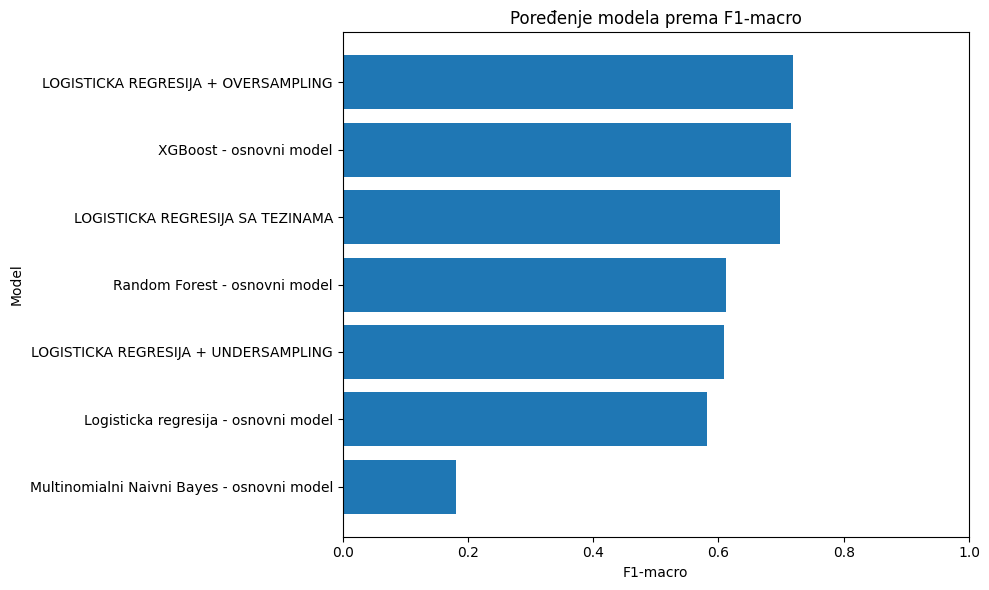

In [33]:
rezultati_sort = rezultati.sort_values("F1_macro", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(rezultati_sort["Model"],rezultati_sort["F1_macro"])
plt.xlabel("F1-macro")
plt.ylabel("Model")
plt.title("Poređenje modela prema F1-macro")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

#GRAFIK - ACCURACY

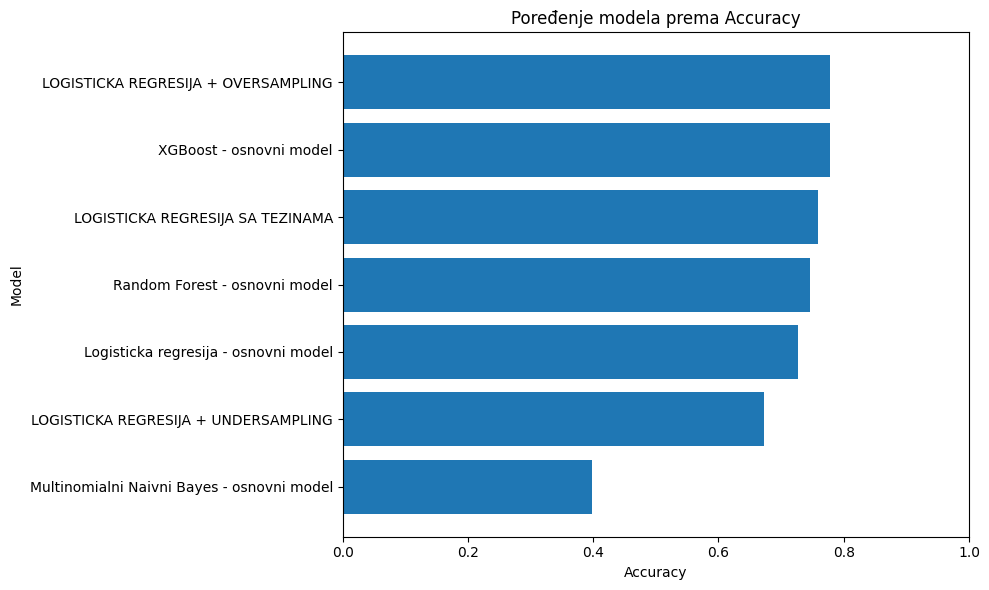

In [34]:
rezultati_sort = rezultati.sort_values("Accuracy",ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(rezultati_sort["Model"],rezultati_sort["Accuracy"])
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.title("Poređenje modela prema Accuracy")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


#GRAFIKON - ROC-AUC

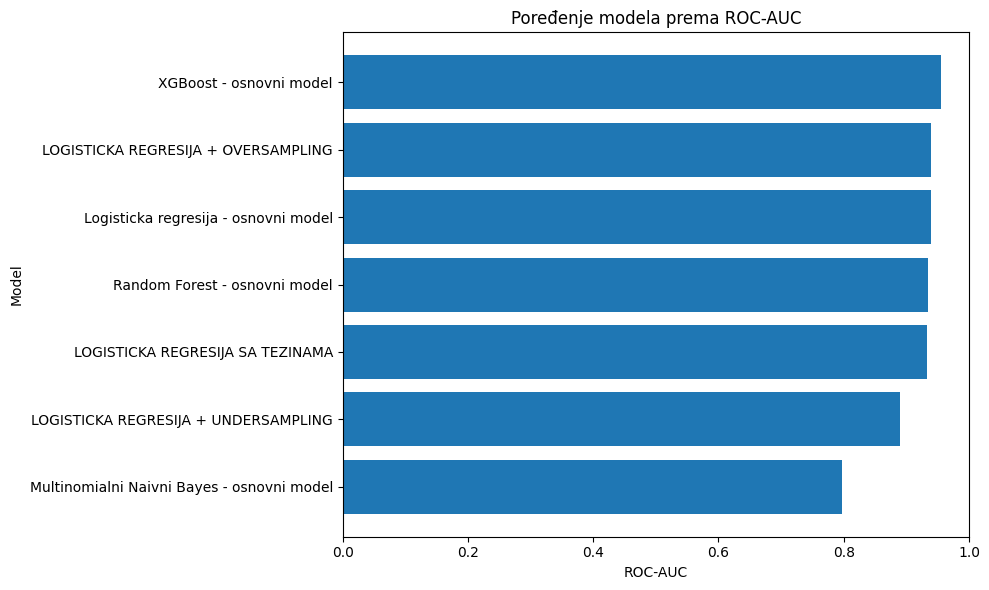

In [35]:
rezultati_sort = rezultati.sort_values("ROC_AUC",ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(rezultati_sort["Model"],rezultati_sort["ROC_AUC"])
plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.title("Poređenje modela prema ROC-AUC")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

#vidimo da su logisticka regresija + oversampling i XGBoost bas slicne sa F1 i Accuracy, ali vidimo da je XGBoost bolji sto se tice AUC, pa biramo XGBoost.

#TEST SKUP:Najbolji model XGBoost

In [37]:
tfidf_final = TfidfVectorizer(lowercase=True,ngram_range=(1, 2),min_df=2,max_df=0.95,max_features=20000,sublinear_tf=True)

#fitujemo TF-IDF na CELom trening skupu:
X_train_final = tfidf_final.fit_transform(train["full_text"])

#test samo transformujemo:
X_test_final = tfidf_final.transform(test["full_text"])

#kodiramo klase:
label_encoder_final = LabelEncoder()
y_train_final = label_encoder_final.fit_transform(train["source"])
y_test_final = label_encoder_final.transform(test["source"])

In [38]:
#finalni XGBoost:
xgb_final = XGBClassifier(n_estimators=100,max_depth=4,learning_rate=0.1,subsample=0.8,colsample_bytree=0.8,random_state=42,n_jobs=-1,eval_metric="mlogloss")


#treniranje na CELOM trening skupu:
xgb_final.fit(X_train_final, y_train_final)


#predikcija na TEST skupu:
y_test_pred = xgb_final.predict(X_test_final)
y_test_proba = xgb_final.predict_proba(X_test_final)


#FINALNA EVALUACIJA:
rezultat_xgb_test = evaluacija_modela(y_test_final,y_test_pred, y_test_proba,"XGBoost - FINALNI MODEL na TEST skupu")


XGBoost - FINALNI MODEL na TEST skupu
Accuracy:           0.8056
Precision (macro):  0.7969
Recall (macro):     0.7183
F1 (macro):         0.7427
Precision (weighted): 0.8161
Recall (weighted):    0.8056
F1 (weighted):        0.8009
ROC-AUC (OvR):        0.9587

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.58      0.68       153
           1       0.70      0.76      0.73       179
           2       0.89      0.57      0.69        44
           3       0.68      0.51      0.58       106
           4       1.00      1.00      1.00       333
           5       0.67      0.90      0.77       224

    accuracy                           0.81      1039
   macro avg       0.80      0.72      0.74      1039
weighted avg       0.82      0.81      0.80      1039


Confusion matrix:
[[ 88  20   0   4   0  41]
 [  9 136   1  19   0  14]
 [  2   0  25   1   0  16]
 [  1  22   1  54   0  28]
 [  0   0   0   0 333   0]
 [  6  15   1   

#finalni XGBoost model je na test skupu ostvario accuracy od 80,6% i macro F1 od 74,3%, sto pokazuje dobru ukupnu uspesnost i relativno uravnoteženo prepoznavanje svih klasa, dok ROC-AUC od 95,9% ukazuje na veoma dobru sposobnost razlikovanja klasa

#prikaz i ispis:

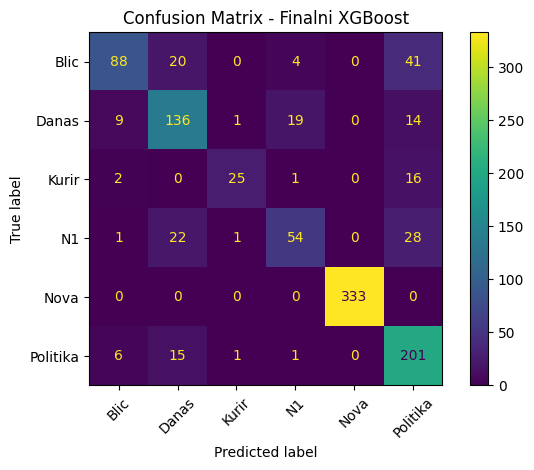

              precision    recall  f1-score      support
Blic           0.830189  0.575163  0.679537   153.000000
Danas          0.704663  0.759777  0.731183   179.000000
Kurir          0.892857  0.568182  0.694444    44.000000
N1             0.683544  0.509434  0.583784   106.000000
Nova           1.000000  1.000000  1.000000   333.000000
Politika       0.670000  0.897321  0.767176   224.000000
accuracy       0.805582  0.805582  0.805582     0.805582
macro avg      0.796876  0.718313  0.742687  1039.000000
weighted avg   0.816145  0.805582  0.800900  1039.000000


In [39]:
#prikaz graficki matrice konfuzije:
ConfusionMatrixDisplay.from_predictions(y_test_final,y_test_pred,display_labels=label_encoder_final.classes_,xticks_rotation=45)

plt.title("Confusion Matrix - Finalni XGBoost")
plt.tight_layout()
plt.show()

#tabelarno:
report = classification_report(y_test_final,y_test_pred,target_names=label_encoder_final.classes_,output_dict=True)
report_df = pd.DataFrame(report).T
print(report_df) #ispis

#vidimo da j emodel najvise pogresno klasifikovao (mesao) Blic i Danas, i, N1 i Danas. Primetimo Novu je bez greske klasifikovao.